
# ROC and Precision–Recall Curves for Imbalanced Classification

Source inspiration: Jason Brownlee, *ROC Curves and Precision-Recall Curves for Imbalanced Classification*, MachineLearningMastery, Sept 16, 2020. See the original tutorial for narrative context and variations.

This notebook recreates the concepts with scikit‑learn code:
- Review of confusion matrix terms used by ROC and PR.
- ROC curve and ROC AUC.
- Precision–Recall curve and PR AUC.
- Behavior under severe class imbalance with baselines.



## Confusion matrix refresher

Binary classes: positive = 1, negative = 0.

- **TP**: predicted 1 and true 1  
- **FP**: predicted 1 but true 0  
- **FN**: predicted 0 but true 1  
- **TN**: predicted 0 and true 0

Key rates:

\[ \text{TPR (Recall)} = \frac{TP}{TP+FN} \quad ; \quad \text{FPR} = \frac{FP}{FP+TN} \]

ROC plots FPR (x) vs TPR (y). PR plots Recall (x) vs Precision (y). Definitions align with the tutorial. 


In [1]:

# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.dummy import DummyClassifier

# Utility: pretty plot wrapper (single-figure, no styles)
def _new_figure(title=None, xlabel=None, ylabel=None):
    plt.figure()
    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)



## Example 1: ROC on a roughly balanced dataset

We create a synthetic binary dataset, split into train and test, train logistic regression, and plot ROC. The diagonal line is a no-skill reference. Approach follows the tutorial.


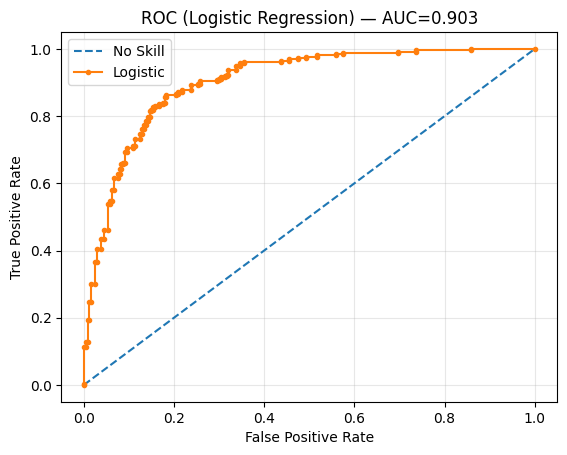

In [2]:

# Synthetic data (roughly balanced)
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

# Logistic regression with probability outputs
lr = LogisticRegression(solver='lbfgs', max_iter=1000)
lr.fit(trainX, trainy)
probs = lr.predict_proba(testX)[:, 1]

# ROC
fpr, tpr, roc_thresholds = roc_curve(testy, probs)
roc_auc = roc_auc_score(testy, probs)

# Plot
_new_figure(title=f'ROC (Logistic Regression) — AUC={roc_auc:.3f}', xlabel='False Positive Rate', ylabel='True Positive Rate')
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
plt.plot(fpr, tpr, marker='.', label='Logistic')
plt.legend()
plt.show()



## Example 2: Precision–Recall on the same dataset

We compute and plot the PR curve. The horizontal dashed line is a no-skill baseline equal to the positive class prevalence. Mirrors the tutorial’s structure. 


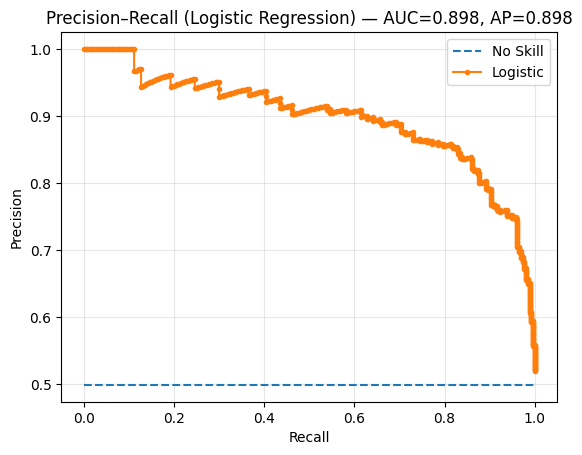

In [3]:

# Baseline: positive class prevalence on the full set
prevalence = (y == 1).mean()

# PR Curve
precision, recall, pr_thresholds = precision_recall_curve(testy, probs)
pr_auc = auc(recall, precision)
avg_prec = average_precision_score(testy, probs)  # AP is threshold-averaged PR; often reported

_new_figure(title=f'Precision–Recall (Logistic Regression) — AUC={pr_auc:.3f}, AP={avg_prec:.3f}',
            xlabel='Recall', ylabel='Precision')
plt.plot([0, 1], [prevalence, prevalence], linestyle='--', label='No Skill')
plt.plot(recall, precision, marker='.', label='Logistic')
plt.legend()
plt.show()



## Example 3: Severe class imbalance

We generate a dataset with 1% positives. We compare:
- A **DummyClassifier** that predicts classes at random according to class priors.
- Logistic Regression.

We report ROC AUC and PR AUC. Under heavy imbalance, PR is more sensitive to improvements on the positive class. Examples follow the tutorial. 


No Skill ROC AUC: 0.492 | PR AUC: 0.007
Logistic  ROC AUC: 0.869 | PR AUC: 0.231


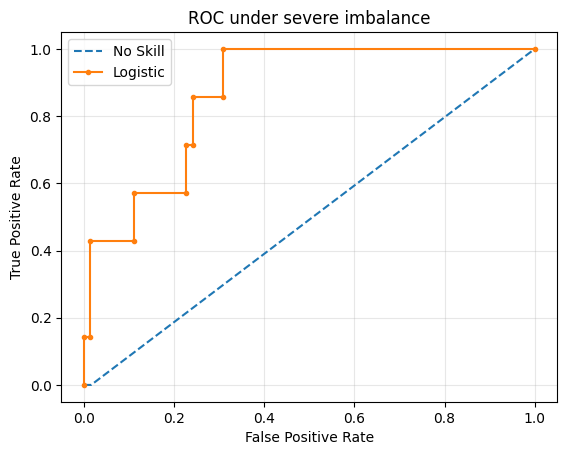

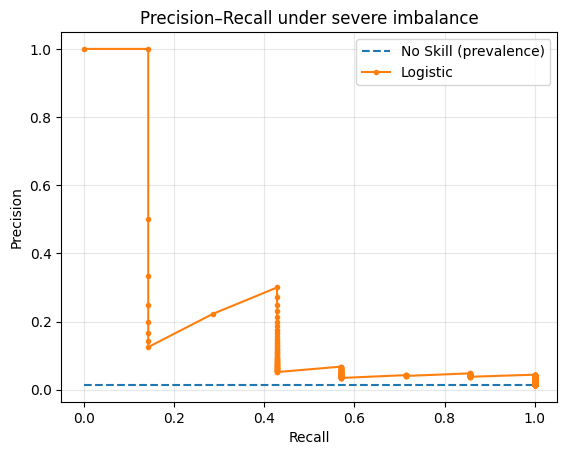

In [4]:

# Imbalanced data: 1% positives
Xi, yi = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)
trainXi, testXi, trainyi, testyi = train_test_split(Xi, yi, test_size=0.5, random_state=2, stratify=yi)

# No-skill baseline (stratified)
dummy = DummyClassifier(strategy='stratified', random_state=0)
dummy.fit(trainXi, trainyi)
dummy_probs = dummy.predict_proba(testXi)[:, 1]

# Logistic regression
lri = LogisticRegression(solver='lbfgs', max_iter=1000)
lri.fit(trainXi, trainyi)
lri_probs = lri.predict_proba(testXi)[:, 1]

# Scores
roc_dummy = roc_auc_score(testyi, dummy_probs)
roc_lri   = roc_auc_score(testyi, lri_probs)

prec_d, rec_d, _ = precision_recall_curve(testyi, dummy_probs)
prec_l, rec_l, _ = precision_recall_curve(testyi, lri_probs)
pr_dummy = auc(rec_d, prec_d)
pr_lri   = auc(rec_l, prec_l)

print(f'No Skill ROC AUC: {roc_dummy:.3f} | PR AUC: {pr_dummy:.3f}')
print(f'Logistic  ROC AUC: {roc_lri:.3f} | PR AUC: {pr_lri:.3f}')

# ROC plot
_new_figure(title='ROC under severe imbalance', xlabel='False Positive Rate', ylabel='True Positive Rate')
fpr_d, tpr_d, _ = roc_curve(testyi, dummy_probs)
fpr_l, tpr_l, _ = roc_curve(testyi, lri_probs)
plt.plot(fpr_d, tpr_d, linestyle='--', label='No Skill')
plt.plot(fpr_l, tpr_l, marker='.', label='Logistic')
plt.legend(); plt.show()

# PR plot
_new_figure(title='Precision–Recall under severe imbalance', xlabel='Recall', ylabel='Precision')
prev_i = (yi == 1).mean()
plt.plot([0, 1], [prev_i, prev_i], linestyle='--', label='No Skill (prevalence)')
plt.plot(rec_l, prec_l, marker='.', label='Logistic')
plt.legend(); plt.show()



## Threshold choice

Both ROC and PR curves are traced by sweeping a decision threshold over the model scores. Below we show how a chosen threshold affects confusion matrix and basic metrics.


In [5]:

from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_at_threshold(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"Threshold={thr:.2f}")
    print("Confusion matrix:\n", cm)
    print(f"Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    return cm, prec, rec, f1

# Example: evaluate logistic model on imbalanced test set with different thresholds
for thr in [0.50, 0.20, 0.10, 0.05]:
    evaluate_at_threshold(testyi, lri_probs, thr)


Threshold=0.50
Confusion matrix:
 [[493   0]
 [  7   0]]
Precision=0.000  Recall=0.000  F1=0.000
Threshold=0.20
Confusion matrix:
 [[492   1]
 [  6   1]]
Precision=0.500  Recall=0.143  F1=0.222
Threshold=0.10
Confusion matrix:
 [[491   2]
 [  6   1]]
Precision=0.333  Recall=0.143  F1=0.200
Threshold=0.05
Confusion matrix:
 [[481  12]
 [  4   3]]
Precision=0.200  Recall=0.429  F1=0.273
